# 08 -- Lane Formation in Bidirectional Flow

This notebook tests whether CrowdRL trained agents spontaneously form **lanes**
when placed in a bidirectional counterflow corridor -- a well-known emergent
phenomenon in pedestrian dynamics that was **never explicitly trained for**.

We replicate the experimental setup from:
- **Feliciani & Nishinari (2016)**, Phys. Rev. E 94, 032304
- **JuPedSim lane-formation notebook** (jupedsim.org)

## Setup
- **Corridor**: 3m wide x 30m long
- **Agents**: 54 total, split into left-to-right and right-to-left groups
- **Flow ratios**: 6/0 (uni), 5/1, 4/2, 3/3 (balanced bidirectional)
- **Model**: Trained ONNX policy from `06_full_training.ipynb`

## Metrics
- Order parameter (Phi) -- measures lane stratification
- Rotation range -- curl of velocity field
- Fundamental diagram (density vs flow)
- Velocity distributions (x and y components)
- Crossing time statistics
- Trajectory visualisation colour-coded by direction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib import cm
from pathlib import Path
from dataclasses import dataclass

import onnxruntime as ort
from shapely.geometry import Polygon, box

from crowdrl_core.world_state import WorldState
from crowdrl_core.geometry import build_navmesh, extract_wall_segments
from crowdrl_core.observation import ObsConfig, build_observations_batch
from crowdrl_core.action import ActionConfig, interpret_actions_batch
from crowdrl_core.collision import (
    detect_collisions,
    compute_contact_forces,
    enforce_wall_boundaries,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 4)

SEED = 42
rng = np.random.default_rng(SEED)
print("Imports OK")

Imports OK


## 1. Load Trained Policy

Load the ONNX policy exported by `06_full_training.ipynb`. The model takes raw
(unnormalised) observations and outputs deterministic action means in [-1, 1].
Normalisation statistics are baked into the ONNX graph.

In [2]:
POLICY_PATH = Path("outputs/06_full_training/policy.onnx")
assert POLICY_PATH.exists(), f"Policy not found at {POLICY_PATH}. Run 06_full_training.ipynb first."

session = ort.InferenceSession(str(POLICY_PATH))
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

input_shape = session.get_inputs()[0].shape
output_shape = session.get_outputs()[0].shape
print(f"ONNX model loaded: {POLICY_PATH}")
print(f"  Input:  {input_name} {input_shape}")
print(f"  Output: {output_name} {output_shape}")
print(f"  File size: {POLICY_PATH.stat().st_size / 1024:.1f} KB")

ONNX model loaded: outputs/06_full_training/policy.onnx
  Input:  observations ['n_agents', 82]
  Output: actions ['n_agents', 4]
  File size: 346.4 KB


In [3]:
def policy_inference(session, observations: np.ndarray) -> np.ndarray:
    """Run ONNX policy on a batch of observations.

    Parameters
    ----------
    session : ort.InferenceSession
    observations : (n_agents, obs_dim) float64 array (raw, unnormalised)

    Returns
    -------
    actions : (n_agents, action_dim) float64 array, values in [-1, 1]
    """
    obs_f32 = observations.astype(np.float32)
    actions = session.run([output_name], {input_name: obs_f32})[0]
    return actions.astype(np.float64)

## 2. Corridor Geometry

Define the bidirectional corridor as a Shapely Polygon. Dimensions match the
JuPedSim `lane-formation.ipynb` notebook (which replicates Feliciani & Nishinari
2016):
- 3m wide corridor, 38m total length
- 12m spawn zones at each end
- 10m central measurement area (x in [14, 24])
- 2m buffer zones between spawn and measurement

Corridor: 38.0m x 3.0m
  Measurement area: x in [14.0, 24.0]
  Walkable area: 114.0 m^2
  Navmesh: 2 triangles


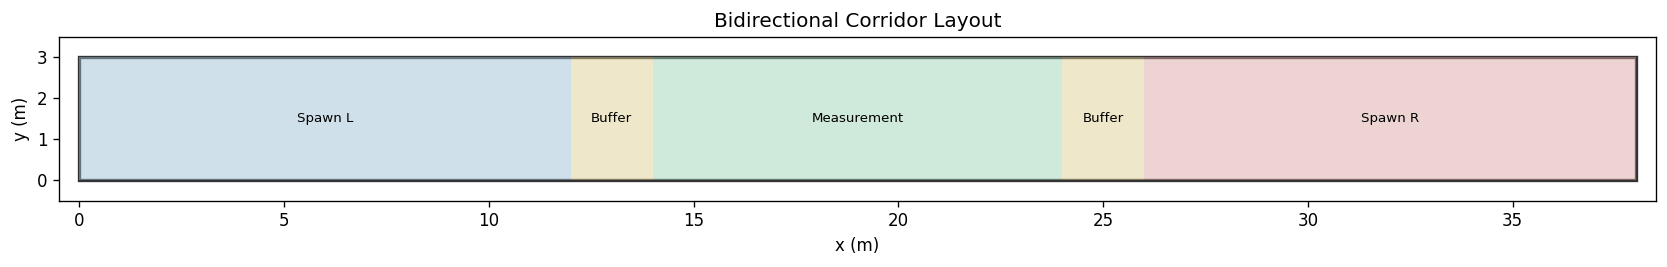

In [4]:
# Corridor dimensions (matching JuPedSim lane-formation.ipynb and
# Feliciani & Nishinari 2016, Fig. 1)
CORRIDOR_WIDTH = 3.0    # m
CORRIDOR_LENGTH = 38.0  # m (total, matching JuPedSim notebook)

# Zones along x-axis (JuPedSim: spawn [0,12]+[26,38], measure [14,24])
SPAWN_LEFT_END = 12.0   # left spawn zone: x in [0, 12]
BUFFER_LEFT = 14.0      # left buffer zone: x in [12, 14]
MEASURE_START = 14.0    # measurement area start
MEASURE_END = 24.0      # measurement area end (10m long)
BUFFER_RIGHT = 24.0    # right buffer zone: x in [24, 26]
SPAWN_RIGHT_START = 26.0  # right spawn zone: x in [26, 38]

# Create walkable polygon
corridor_polygon = box(0, 0, CORRIDOR_LENGTH, CORRIDOR_WIDTH)
print(f"Corridor: {CORRIDOR_LENGTH}m x {CORRIDOR_WIDTH}m")
print(f"  Measurement area: x in [{MEASURE_START}, {MEASURE_END}]")
print(f"  Walkable area: {corridor_polygon.area:.1f} m^2")

# Build navmesh for observation builder
navmesh = build_navmesh(corridor_polygon)
wall_segments = extract_wall_segments(corridor_polygon)
print(f"  Navmesh: {len(navmesh.triangles)} triangles")

# Visualise
fig, ax = plt.subplots(figsize=(14, 3))
coords = np.array(corridor_polygon.exterior.coords)
poly_patch = mpatches.Polygon(coords, facecolor="#e8e8e8", edgecolor="#333", lw=2)
ax.add_patch(poly_patch)

# Mark zones
for xstart, xend, color, label in [
    (0, SPAWN_LEFT_END, "#aed6f1", "Spawn L"),
    (SPAWN_LEFT_END, BUFFER_LEFT, "#f9e79f", "Buffer"),
    (MEASURE_START, MEASURE_END, "#abebc6", "Measurement"),
    (BUFFER_RIGHT, SPAWN_RIGHT_START, "#f9e79f", "Buffer"),
    (SPAWN_RIGHT_START, CORRIDOR_LENGTH, "#f5b7b1", "Spawn R"),
]:
    rect = mpatches.Rectangle(
        (xstart, 0), xend - xstart, CORRIDOR_WIDTH,
        facecolor=color, alpha=0.4, edgecolor="none"
    )
    ax.add_patch(rect)
    ax.text((xstart + xend) / 2, CORRIDOR_WIDTH / 2, label,
            ha="center", va="center", fontsize=8)

ax.set_xlim(-0.5, CORRIDOR_LENGTH + 0.5)
ax.set_ylim(-0.5, CORRIDOR_WIDTH + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Bidirectional Corridor Layout")
plt.tight_layout()
plt.show()

## 3. Agent Spawning

Spawn agents in grid formation in the waiting areas, matching the Feliciani
experiment (9 columns, 6 rows per side = 54 positions per side).

In [5]:
@dataclass
class FlowConfig:
    """Configuration for a bidirectional flow experiment."""
    name: str
    n_left: int   # agents moving left-to-right
    n_right: int  # agents moving right-to-left

    @property
    def n_total(self) -> int:
        return self.n_left + self.n_right

    @property
    def flow_ratio(self) -> float:
        if self.n_total == 0:
            return 0.0
        return self.n_right / self.n_total


# Feliciani & Nishinari (2016), Table I
FLOW_CONFIGS = [
    FlowConfig("6/0 (uni)",    n_left=54, n_right=0),
    FlowConfig("5/1 (r=0.17)", n_left=45, n_right=9),
    FlowConfig("4/2 (r=0.33)", n_left=36, n_right=18),
    FlowConfig("3/3 (r=0.50)", n_left=27, n_right=27),
]

for fc in FLOW_CONFIGS:
    print(f"{fc.name}: {fc.n_left}L + {fc.n_right}R = {fc.n_total}, r={fc.flow_ratio:.3f}")

6/0 (uni): 54L + 0R = 54, r=0.000
5/1 (r=0.17): 45L + 9R = 54, r=0.167
4/2 (r=0.33): 36L + 18R = 54, r=0.333
3/3 (r=0.50): 27L + 27R = 54, r=0.500


In [6]:
# Body dimension distributions (from crowdrl-env SpawnConfig defaults)
SHOULDER_WIDTH_MEAN = 0.22  # half-width (m) -- full shoulder ~0.44m
SHOULDER_WIDTH_STD = 0.02
CHEST_DEPTH_MEAN = 0.14     # half-depth (m) -- full chest ~0.28m
CHEST_DEPTH_STD = 0.015
PREFERRED_SPEED_MEAN = 1.34  # m/s (Weidmann)
PREFERRED_SPEED_STD = 0.10   # matching Feliciani: 1.40 +/- 0.10


def spawn_grid(rng, x_start, x_end, y_start, y_end, n_agents, n_cols=9):
    """Spawn agents in a grid formation within a rectangular zone.

    Returns positions (n, 2) in the zone.
    """
    n_rows = int(np.ceil(n_agents / n_cols))
    # Grid spacing
    dx = (x_end - x_start) / max(n_cols, 1)
    dy = (y_end - y_start) / max(n_rows + 1, 2)

    positions = []
    for row in range(n_rows):
        for col in range(n_cols):
            if len(positions) >= n_agents:
                break
            x = x_start + dx * (col + 0.5)
            y = y_start + dy * (row + 1)
            # Small jitter to avoid perfect alignment
            x += rng.normal(0, 0.05)
            y += rng.normal(0, 0.05)
            y = np.clip(y, y_start + 0.3, y_end - 0.3)
            positions.append([x, y])

    return np.array(positions[:n_agents])


def create_world_state(
    rng, flow_config: FlowConfig, polygon, navmesh_data, wall_segs
) -> tuple[WorldState, np.ndarray, np.ndarray]:
    """Create a WorldState for a bidirectional flow experiment.

    Returns (world_state, preferred_speeds, direction_labels)
    where direction_labels[i] = +1 (left-to-right) or -1 (right-to-left).
    """
    n = flow_config.n_total

    # Spawn left-to-right agents in left zone
    pos_left = spawn_grid(
        rng, 1.0, SPAWN_LEFT_END - 0.5,
        0.3, CORRIDOR_WIDTH - 0.3, flow_config.n_left
    )
    # Spawn right-to-left agents in right zone
    pos_right = spawn_grid(
        rng, SPAWN_RIGHT_START + 0.5, CORRIDOR_LENGTH - 1.0,
        0.3, CORRIDOR_WIDTH - 0.3, flow_config.n_right
    )

    positions = np.vstack([pos_left, pos_right]) if flow_config.n_right > 0 else pos_left

    # Goals: left-to-right agents aim for right end, vice versa
    goal_left = np.column_stack([
        rng.uniform(CORRIDOR_LENGTH - 2.0, CORRIDOR_LENGTH - 0.5, flow_config.n_left),
        rng.uniform(0.5, CORRIDOR_WIDTH - 0.5, flow_config.n_left),
    ])
    if flow_config.n_right > 0:
        goal_right = np.column_stack([
            rng.uniform(0.5, 2.0, flow_config.n_right),
            rng.uniform(0.5, CORRIDOR_WIDTH - 0.5, flow_config.n_right),
        ])
        goal_positions = np.vstack([goal_left, goal_right])
    else:
        goal_positions = goal_left

    # Direction labels
    dir_labels = np.concatenate([
        np.ones(flow_config.n_left),
        -np.ones(flow_config.n_right),
    ])

    # Body dimensions
    shoulder_widths = np.abs(rng.normal(SHOULDER_WIDTH_MEAN, SHOULDER_WIDTH_STD, n))
    chest_depths = np.abs(rng.normal(CHEST_DEPTH_MEAN, CHEST_DEPTH_STD, n))

    # Initial orientations: face toward goal
    torso_orientations = np.where(dir_labels > 0, 0.0, np.pi)  # 0=right, pi=left
    head_orientations = torso_orientations.copy()

    # Initial velocities: zero (standing start)
    velocities = np.zeros((n, 2))

    # Preferred speeds
    preferred_speeds = np.abs(rng.normal(PREFERRED_SPEED_MEAN, PREFERRED_SPEED_STD, n))

    world = WorldState(
        positions=positions,
        velocities=velocities,
        torso_orientations=torso_orientations,
        head_orientations=head_orientations,
        shoulder_widths=shoulder_widths,
        chest_depths=chest_depths,
        masses=np.full(n, 80.0, dtype=np.float64),
        goal_positions=goal_positions,
        walkable_polygon=polygon,
        wall_segments=wall_segs,
        navmesh=navmesh_data,
        active_mask=np.ones(n, dtype=np.bool_),
    )
    world.validate()

    return world, preferred_speeds, dir_labels


# Test spawn
test_world, test_speeds, test_dirs = create_world_state(
    rng, FLOW_CONFIGS[3], corridor_polygon, navmesh, wall_segments
)
print(f"Spawned {test_world.n_agents} agents for {FLOW_CONFIGS[3].name}")
print(f"  Left-to-right: {np.sum(test_dirs > 0)}, Right-to-left: {np.sum(test_dirs < 0)}")

Spawned 54 agents for 3/3 (r=0.50)
  Left-to-right: 27, Right-to-left: 27


## 4. Simulation Loop

Run the corridor simulation using the trained ONNX policy. This bypasses
CrowdEnv and drives the physics directly, since we need custom geometry and
spawning (not procedurally generated).

In [7]:
# Simulation parameters (matching training env)
DT = 0.01                   # timestep (s)
MAX_STEPS = 15000           # 150s sim time (matching JuPedSim: 3000 iters * 0.05s)
VELOCITY_DAMPING = 0.8
CONTACT_STIFFNESS = 30000.0   # N per unit overlap (calibrated against JuPedSim SFM k=120kN/m)
CONTACT_DAMPING = 500.0       # N*s/m (velocity-dependent damping)
MAX_SPEED = 1.5
MAX_SPEED_MULTIPLIER = 2.0
GOAL_RADIUS = 1.0           # distance to goal to count as reached

# Observation/action configs (must match training)
obs_config = ObsConfig(use_navmesh=True)  # 82D (matches 06_full_training)
action_config = ActionConfig()             # 4D

# Recording interval (save state every N steps for trajectory analysis)
RECORD_INTERVAL = 1  # every 0.1s -> 10 Hz output

print(f"Simulation: dt={DT}s, max_steps={MAX_STEPS} ({MAX_STEPS * DT:.0f}s)")
print(f"Observation: {obs_config.obs_dim}D, Action: {action_config.action_dim}D")
print(f"Recording at {1/(DT*RECORD_INTERVAL):.0f} Hz")

Simulation: dt=0.01s, max_steps=15000 (150s)
Observation: 82D, Action: 4D
Recording at 100 Hz


In [8]:
@dataclass
class TrajectoryRecord:
    """Recorded trajectory data for analysis."""
    times: np.ndarray          # (T,) timestamps
    positions: np.ndarray      # (T, n_agents, 2)
    velocities: np.ndarray     # (T, n_agents, 2)
    torso_angles: np.ndarray   # (T, n_agents)
    head_angles: np.ndarray    # (T, n_agents)
    active_mask: np.ndarray    # (T, n_agents) bool
    dir_labels: np.ndarray     # (n_agents,) +1 or -1
    goal_positions: np.ndarray # (n_agents, 2)
    polygon: Polygon
    n_agents: int
    reached_goal: np.ndarray   # (n_agents,) bool


def run_simulation(
    session, world: WorldState, preferred_speeds: np.ndarray,
    dir_labels: np.ndarray, polygon: Polygon,
    max_steps: int = MAX_STEPS,
) -> TrajectoryRecord:
    """Run a full corridor simulation with the ONNX policy."""
    n = world.n_agents
    active = world.active_mask.copy()
    reached = np.zeros(n, dtype=np.bool_)

    # Pre-allocate recording buffers
    n_records = max_steps // RECORD_INTERVAL + 1
    rec_times = np.zeros(n_records)
    rec_pos = np.zeros((n_records, n, 2))
    rec_vel = np.zeros((n_records, n, 2))
    rec_torso = np.zeros((n_records, n))
    rec_head = np.zeros((n_records, n))
    rec_active = np.zeros((n_records, n), dtype=np.bool_)
    rec_idx = 0

    # Record initial state
    rec_times[0] = 0.0
    rec_pos[0] = world.positions.copy()
    rec_vel[0] = world.velocities.copy()
    rec_torso[0] = world.torso_orientations.copy()
    rec_head[0] = world.head_orientations.copy()
    rec_active[0] = active.copy()
    rec_idx = 1

    for step in range(1, max_steps + 1):
        # 1. Build observations
        obs = build_observations_batch(world, obs_config)

        # 2. Policy inference
        actions = policy_inference(session, obs)

        # Zero actions for inactive agents
        actions[~active] = 0.0

        # 3. Interpret actions
        batch_result = interpret_actions_batch(
            actions,
            world.torso_orientations,
            world.torso_orientations,
            world.head_orientations,
            action_config,
        )

        # 4. Velocity update (damped blending)
        world.velocities[active] = (
            VELOCITY_DAMPING * batch_result.desired_velocities[active]
            + (1.0 - VELOCITY_DAMPING) * world.velocities[active]
        )
        world.torso_orientations[active] = batch_result.new_torso_orientations[active]
        world.head_orientations[active] = batch_result.new_head_orientations[active]

        # 5. Contact accelerations (force / mass, via compute_contact_forces)
        collisions = detect_collisions(world)
        accel = compute_contact_forces(
            world, stiffness=CONTACT_STIFFNESS, damping=CONTACT_DAMPING,
            collisions=collisions,
        )
        world.velocities[active] += accel[active] * DT

        # Clamp speeds
        max_vel = MAX_SPEED_MULTIPLIER * MAX_SPEED
        speeds = np.linalg.norm(world.velocities[active], axis=1)
        too_fast = speeds > max_vel
        if np.any(too_fast):
            scale = np.where(too_fast, max_vel / np.maximum(speeds, 1e-10), 1.0)
            world.velocities[active] *= scale[:, np.newaxis]

        # 6. Position update
        world.positions[active] += world.velocities[active] * DT
        enforce_wall_boundaries(world)

        # 7. Check goal reached
        goal_dist = np.linalg.norm(
            world.positions - world.goal_positions, axis=1
        )
        newly_reached = (goal_dist < GOAL_RADIUS) & active & ~reached
        reached |= newly_reached
        active[newly_reached] = False
        world.active_mask = active
        world.velocities[~active] = 0.0

        # 8. Record
        if step % RECORD_INTERVAL == 0 and rec_idx < n_records:
            rec_times[rec_idx] = step * DT
            rec_pos[rec_idx] = world.positions.copy()
            rec_vel[rec_idx] = world.velocities.copy()
            rec_torso[rec_idx] = world.torso_orientations.copy()
            rec_head[rec_idx] = world.head_orientations.copy()
            rec_active[rec_idx] = active.copy()
            rec_idx += 1

        # All done?
        if not np.any(active):
            break

    # Trim to actual recorded length
    rec_times = rec_times[:rec_idx]
    rec_pos = rec_pos[:rec_idx]
    rec_vel = rec_vel[:rec_idx]
    rec_torso = rec_torso[:rec_idx]
    rec_head = rec_head[:rec_idx]
    rec_active = rec_active[:rec_idx]

    final_step = step
    n_reached = np.sum(reached)
    print(f"  Simulation ended at step {final_step} ({final_step*DT:.1f}s)")
    print(f"  Agents reached goal: {n_reached}/{n} ({100*n_reached/n:.0f}%)")

    return TrajectoryRecord(
        times=rec_times, positions=rec_pos, velocities=rec_vel,
        torso_angles=rec_torso, head_angles=rec_head, active_mask=rec_active,
        dir_labels=dir_labels, goal_positions=world.goal_positions.copy(),
        polygon=polygon, n_agents=n, reached_goal=reached,
    )

## 5. Run All Flow Configurations

In [9]:
results = {}

for fc in FLOW_CONFIGS:
    print(f"\n=== {fc.name} (r={fc.flow_ratio:.3f}) ===")
    run_rng = np.random.default_rng(SEED)

    world, speeds, dirs = create_world_state(
        run_rng, fc, corridor_polygon, navmesh, wall_segments
    )

    record = run_simulation(
        session, world, speeds, dirs, corridor_polygon
    )
    results[fc.name] = record

print("\nAll simulations complete.")


=== 6/0 (uni) (r=0.000) ===
  Simulation ended at step 2430 (24.3s)
  Agents reached goal: 54/54 (100%)

=== 5/1 (r=0.17) (r=0.167) ===
  Simulation ended at step 2944 (29.4s)
  Agents reached goal: 54/54 (100%)

=== 4/2 (r=0.33) (r=0.333) ===
  Simulation ended at step 2907 (29.1s)
  Agents reached goal: 54/54 (100%)

=== 3/3 (r=0.50) (r=0.500) ===
  Simulation ended at step 3429 (34.3s)
  Agents reached goal: 54/54 (100%)

All simulations complete.


## 6. Trajectory Visualisation

Plot agent trajectories colour-coded by walking direction, matching Feliciani
Fig. 6 (x-velocity gradation).

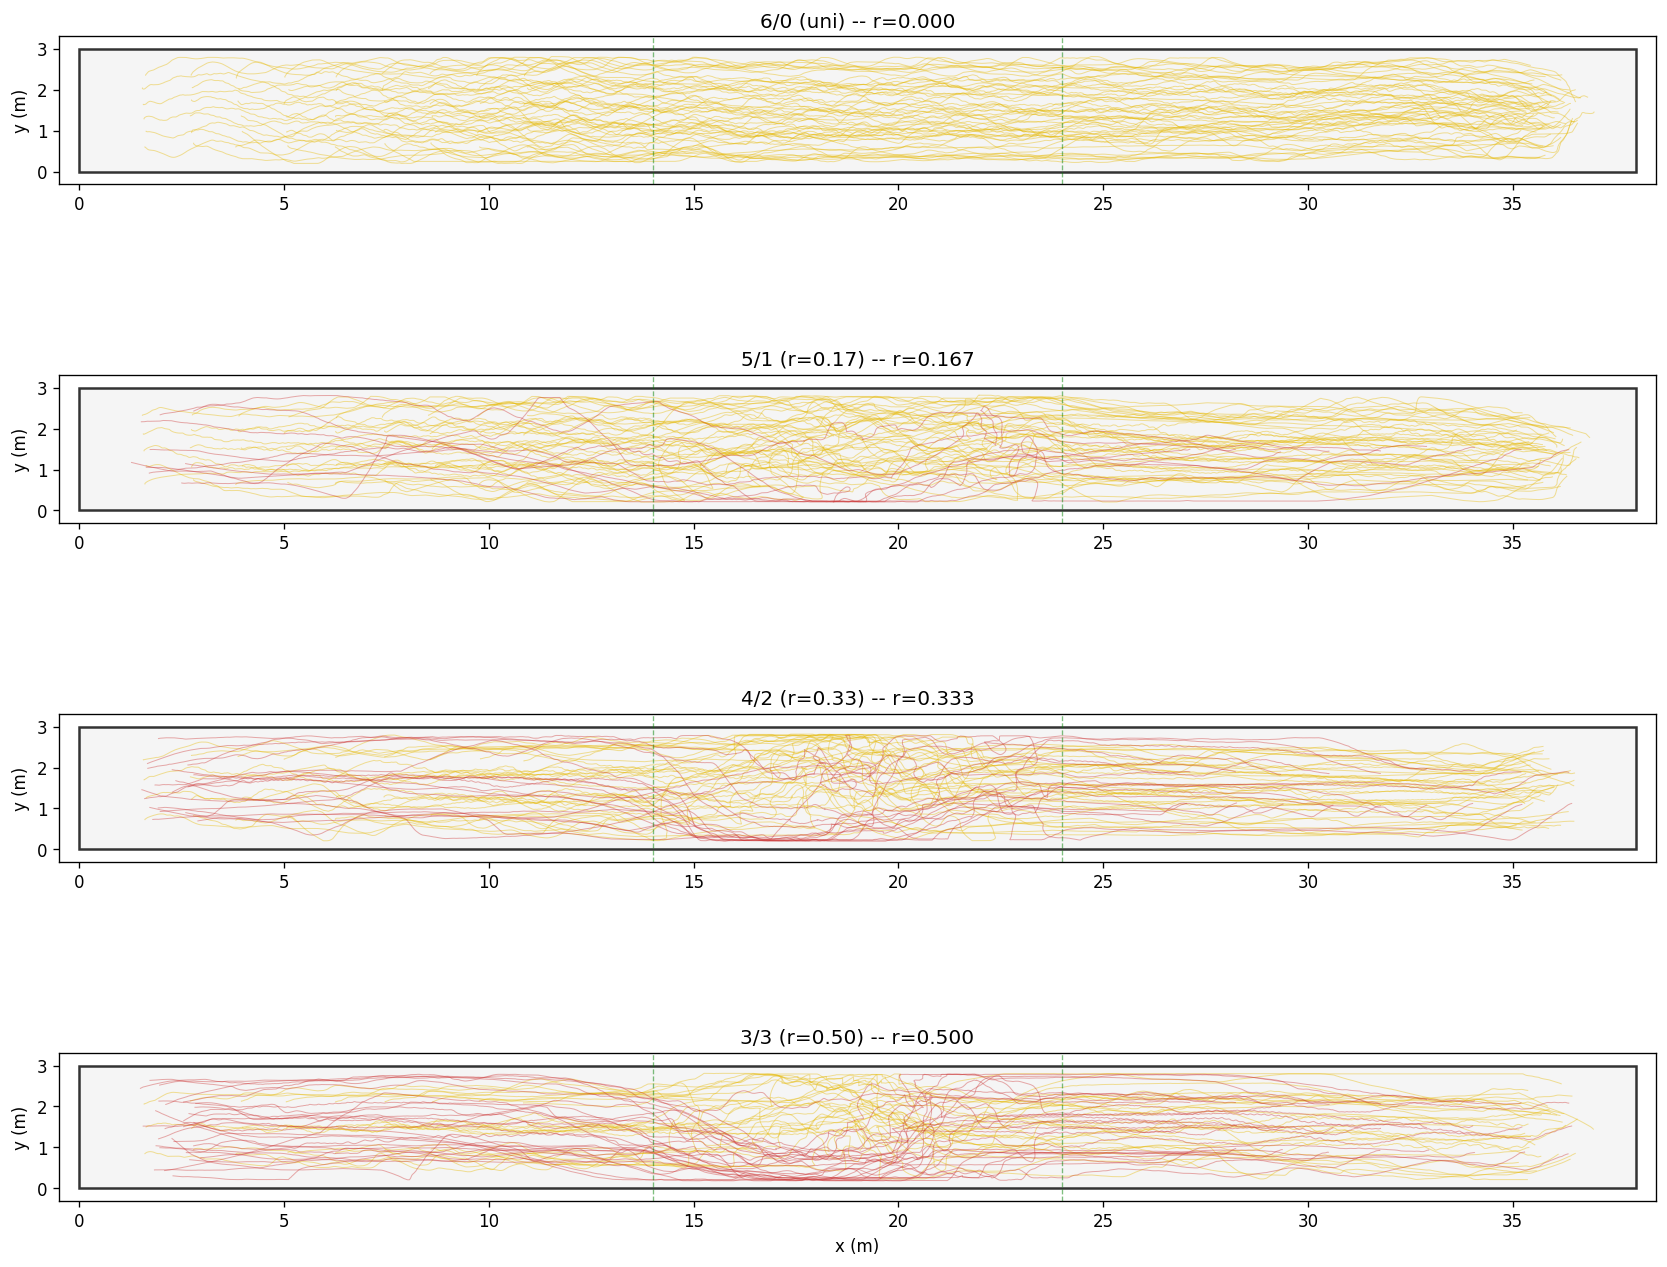

In [10]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 3 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax, (name, rec) in zip(axes, results.items()):
    # Draw corridor
    coords = np.array(corridor_polygon.exterior.coords)
    ax.add_patch(mpatches.Polygon(coords, fc="#f5f5f5", ec="#333", lw=1.5))

    # Draw trajectories for each agent
    for i in range(rec.n_agents):
        # Get trajectory while agent was active
        active_frames = rec.active_mask[:, i]
        # Include a few frames beyond deactivation for continuity
        traj = rec.positions[:, i, :]

        if rec.dir_labels[i] > 0:
            color = "#e6b800"  # yellow/gold for left-to-right (major flow)
        else:
            color = "#cc3333"  # red for right-to-left (minor flow)

        ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.4, lw=0.6)

    # Measurement area box
    ax.axvline(MEASURE_START, color="green", ls="--", alpha=0.5, lw=0.8)
    ax.axvline(MEASURE_END, color="green", ls="--", alpha=0.5, lw=0.8)

    ax.set_xlim(-0.5, CORRIDOR_LENGTH + 0.5)
    ax.set_ylim(-0.3, CORRIDOR_WIDTH + 0.3)
    ax.set_aspect("equal")
    ax.set_ylabel("y (m)")
    ax.set_title(f"{name} -- r={rec.dir_labels[rec.dir_labels < 0].size / rec.n_agents:.3f}")

axes[-1].set_xlabel("x (m)")
fig.tight_layout()
plt.show()

## 7. Order Parameter (Lane Formation Metric)

The order parameter Phi quantifies lane stratification (Feliciani & Nishinari
2016, Eq. 6-7; Rex & Lowen 2007). The measurement area is divided into a grid.
For each row, we count left-movers vs right-movers:

$$\phi_j = \left(\frac{n_j^L - n_j^R}{n_j^L + n_j^R}\right)^2$$

$$\Phi = \frac{1}{N} \sum_{j=1}^{N} \phi_j$$

- Phi = 1: perfect lanes (each row has only one direction)
- Phi -> 0: random mixing

In [11]:
def compute_order_parameter(
    positions: np.ndarray,
    velocities: np.ndarray,
    active_mask: np.ndarray,
    dir_labels: np.ndarray,
    y_min: float = 0.0,
    y_max: float = CORRIDOR_WIDTH,
    x_min: float = MEASURE_START,
    x_max: float = MEASURE_END,
    cell_size: float = 0.2,
) -> float:
    """Compute the order parameter Phi for a single time frame.

    Parameters
    ----------
    positions : (n_agents, 2)
    velocities : (n_agents, 2)
    active_mask : (n_agents,) bool
    dir_labels : (n_agents,) +1 or -1
    cell_size : grid cell size (m), default 0.2m per Feliciani

    Returns
    -------
    Phi : float in [0, 1]
    """
    # Filter to measurement area and active agents
    in_area = (
        active_mask
        & (positions[:, 0] >= x_min) & (positions[:, 0] <= x_max)
        & (positions[:, 1] >= y_min) & (positions[:, 1] <= y_max)
    )

    if np.sum(in_area) < 2:
        return np.nan

    pos = positions[in_area]
    dirs = dir_labels[in_area]

    # Discretise y-positions into rows
    n_rows = int(np.ceil((y_max - y_min) / cell_size))
    row_indices = np.clip(
        ((pos[:, 1] - y_min) / cell_size).astype(int), 0, n_rows - 1
    )

    phi_values = []
    for j in range(n_rows):
        in_row = row_indices == j
        if np.sum(in_row) == 0:
            continue
        n_L = np.sum(dirs[in_row] > 0)  # left-to-right
        n_R = np.sum(dirs[in_row] < 0)  # right-to-left
        total = n_L + n_R
        if total > 0:
            phi_j = ((n_L - n_R) / total) ** 2
            phi_values.append(phi_j)

    if not phi_values:
        return np.nan

    return float(np.mean(phi_values))


def compute_order_parameter_timeseries(rec: TrajectoryRecord) -> tuple[np.ndarray, np.ndarray]:
    """Compute order parameter over time for a trajectory record."""
    times = []
    phis = []
    for t_idx in range(len(rec.times)):
        phi = compute_order_parameter(
            rec.positions[t_idx],
            rec.velocities[t_idx],
            rec.active_mask[t_idx],
            rec.dir_labels,
        )
        times.append(rec.times[t_idx])
        phis.append(phi)
    return np.array(times), np.array(phis)

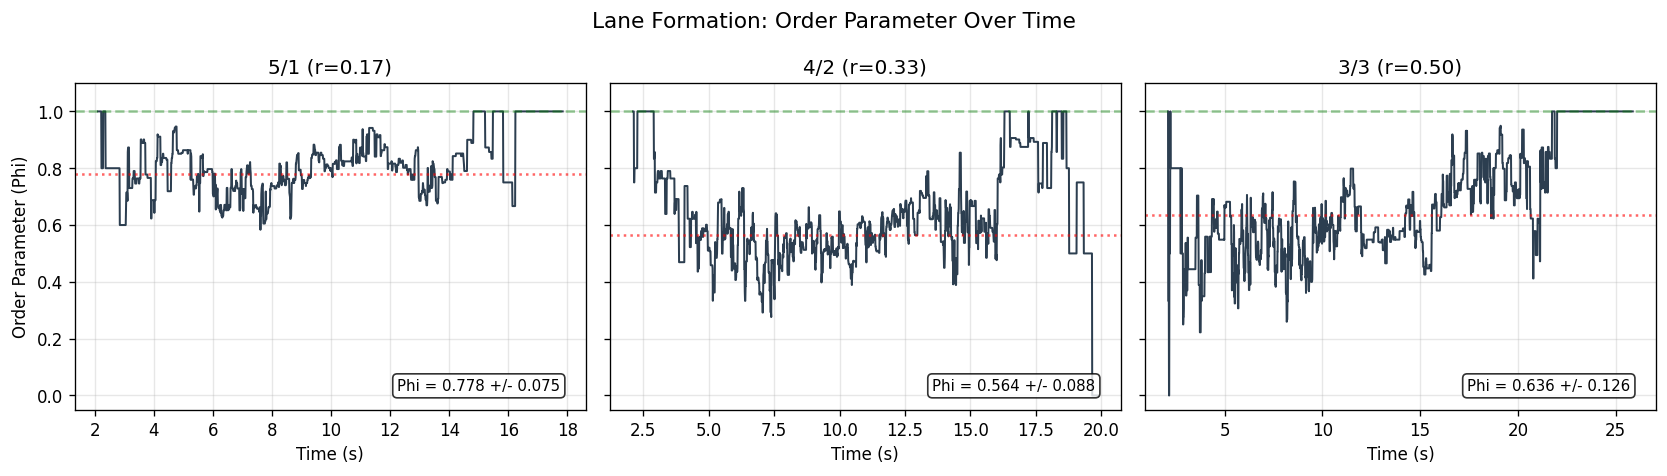


Order parameter summary (mid-simulation mean):
  5/1 (r=0.17): Phi = 0.778 +/- 0.075
  4/2 (r=0.33): Phi = 0.564 +/- 0.088
  3/3 (r=0.50): Phi = 0.636 +/- 0.126

Reference (Feliciani & Nishinari 2016, Table V):
  5/1: Phi = 0.824 +/- 0.130
  4/2: Phi = 0.881 +/- 0.131
  3/3: Phi = 0.938 +/- 0.105


In [12]:
# Compute and plot order parameter for all bidirectional configurations
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

phi_summary = {}

for ax, (name, rec) in zip(axes, [(n, r) for n, r in results.items() if r.dir_labels.min() < 0]):
    times, phis = compute_order_parameter_timeseries(rec)
    valid = ~np.isnan(phis)

    ax.plot(times[valid], phis[valid], lw=1.2, color="#2c3e50")
    ax.axhline(1.0, color="green", ls="--", alpha=0.4, label="Perfect lanes")
    ax.set_xlabel("Time (s)")
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)

    # Mean during full bidirectional phase (middle 50% of simulation)
    t_start = times[valid][len(times[valid]) // 4]
    t_end = times[valid][3 * len(times[valid]) // 4]
    mid_mask = valid & (times >= t_start) & (times <= t_end)
    if np.any(mid_mask):
        mean_phi = np.nanmean(phis[mid_mask])
        std_phi = np.nanstd(phis[mid_mask])
        phi_summary[name] = (mean_phi, std_phi)
        ax.axhline(mean_phi, color="red", ls=":", alpha=0.6)
        ax.text(0.95, 0.05, f"Phi = {mean_phi:.3f} +/- {std_phi:.3f}",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

axes[0].set_ylabel("Order Parameter (Phi)")
fig.suptitle("Lane Formation: Order Parameter Over Time", fontsize=13)
fig.tight_layout()
plt.show()

print("\nOrder parameter summary (mid-simulation mean):")
for name, (mean, std) in phi_summary.items():
    print(f"  {name}: Phi = {mean:.3f} +/- {std:.3f}")

print("\nReference (Feliciani & Nishinari 2016, Table V):")
print("  5/1: Phi = 0.824 +/- 0.130")
print("  4/2: Phi = 0.881 +/- 0.131")
print("  3/3: Phi = 0.938 +/- 0.105")

## 8. Rotation Range

Rotation range measures the curl of the velocity vector field on a 2D grid
(Feliciani & Nishinari 2016, Eq. 8-9). Low rotation range indicates laminar
flow (well-formed lanes); high rotation range indicates turbulent mixing.

In [13]:
def compute_rotation_range(
    positions: np.ndarray,
    velocities: np.ndarray,
    active_mask: np.ndarray,
    x_min: float = MEASURE_START,
    x_max: float = MEASURE_END,
    y_min: float = 0.0,
    y_max: float = CORRIDOR_WIDTH,
    cell_size: float = 0.2,
) -> float:
    """Compute the rotation range of the velocity field.

    Grid the measurement area, compute mean velocity per cell, then compute
    the curl (r_z = dFy/dx - dFx/dy) and return max(r_z) - min(r_z).
    """
    in_area = (
        active_mask
        & (positions[:, 0] >= x_min) & (positions[:, 0] <= x_max)
        & (positions[:, 1] >= y_min) & (positions[:, 1] <= y_max)
    )

    if np.sum(in_area) < 4:
        return np.nan

    pos = positions[in_area]
    vel = velocities[in_area]

    nx = int(np.ceil((x_max - x_min) / cell_size))
    ny = int(np.ceil((y_max - y_min) / cell_size))

    # Bin velocities into grid cells
    vx_grid = np.full((ny, nx), np.nan)
    vy_grid = np.full((ny, nx), np.nan)

    ix = np.clip(((pos[:, 0] - x_min) / cell_size).astype(int), 0, nx - 1)
    iy = np.clip(((pos[:, 1] - y_min) / cell_size).astype(int), 0, ny - 1)

    for ci in range(nx):
        for cj in range(ny):
            mask = (ix == ci) & (iy == cj)
            if np.sum(mask) > 0:
                vx_grid[cj, ci] = np.mean(vel[mask, 0])
                vy_grid[cj, ci] = np.mean(vel[mask, 1])

    # Compute curl using finite differences (central where possible)
    # r_z = dFy/dx - dFx/dy
    rz = np.full((ny, nx), np.nan)
    for j in range(1, ny - 1):
        for i in range(1, nx - 1):
            if (np.isnan(vx_grid[j, i]) or np.isnan(vy_grid[j, i])):
                continue
            # dFy/dx
            if not np.isnan(vy_grid[j, i+1]) and not np.isnan(vy_grid[j, i-1]):
                dFy_dx = (vy_grid[j, i+1] - vy_grid[j, i-1]) / (2 * cell_size)
            else:
                continue
            # dFx/dy
            if not np.isnan(vx_grid[j+1, i]) and not np.isnan(vx_grid[j-1, i]):
                dFx_dy = (vx_grid[j+1, i] - vx_grid[j-1, i]) / (2 * cell_size)
            else:
                continue
            rz[j, i] = dFy_dx - dFx_dy

    valid_rz = rz[~np.isnan(rz)]
    if len(valid_rz) < 2:
        return np.nan

    return float(np.max(valid_rz) - np.min(valid_rz))


# Compute rotation range at the midpoint of each simulation
print("Rotation range at mid-simulation:")
for name, rec in results.items():
    mid_idx = len(rec.times) // 2
    rr = compute_rotation_range(
        rec.positions[mid_idx], rec.velocities[mid_idx], rec.active_mask[mid_idx]
    )
    print(f"  {name}: R = {rr:.2f} s^-1" if not np.isnan(rr) else f"  {name}: R = N/A")

Rotation range at mid-simulation:
  6/0 (uni): R = N/A
  5/1 (r=0.17): R = N/A
  4/2 (r=0.33): R = N/A
  3/3 (r=0.50): R = N/A


## 9. Fundamental Diagram

Density vs flow scatter plot, computed using spatial binning in the measurement
area. Each point represents one time frame, with density (persons/m^2) and flow
(persons/(m*s)) computed from the measurement area.

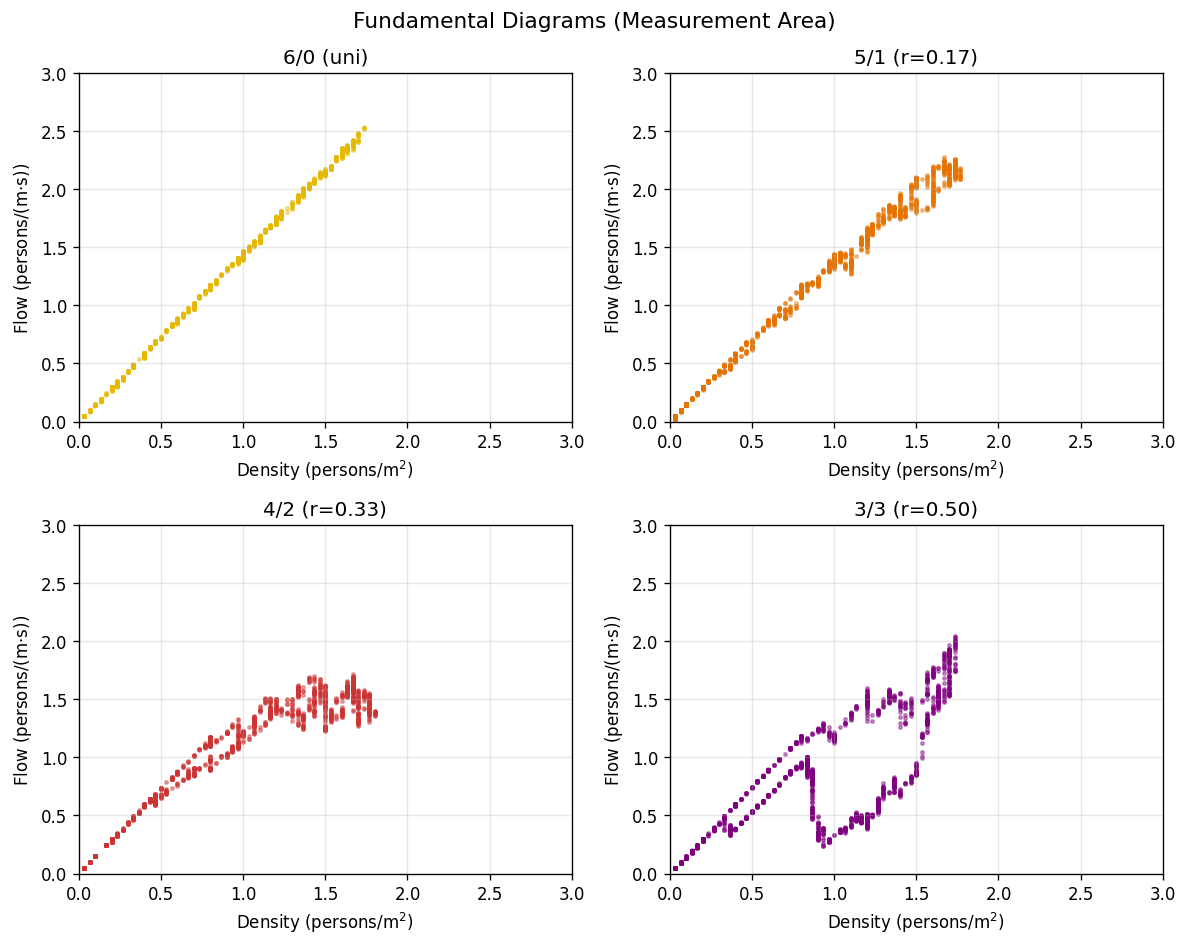

In [14]:
def compute_fundamental_diagram(
    rec: TrajectoryRecord,
    x_min: float = MEASURE_START,
    x_max: float = MEASURE_END,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute density-flow pairs for each time frame.

    Returns (densities, flows) arrays of shape (T,).
    """
    area = (x_max - x_min) * CORRIDOR_WIDTH
    densities = []
    flows = []

    for t_idx in range(len(rec.times)):
        pos = rec.positions[t_idx]
        vel = rec.velocities[t_idx]
        active = rec.active_mask[t_idx]

        in_area = (
            active
            & (pos[:, 0] >= x_min) & (pos[:, 0] <= x_max)
        )

        n_in_area = np.sum(in_area)
        if n_in_area == 0:
            densities.append(0.0)
            flows.append(0.0)
            continue

        rho = n_in_area / area
        # Flow = density * mean |x-velocity|
        mean_vx = np.mean(np.abs(vel[in_area, 0]))
        J = rho * mean_vx

        densities.append(rho)
        flows.append(J)

    return np.array(densities), np.array(flows)


# Plot fundamental diagrams
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
colors_map = ["#e6b800", "#e67300", "#cc3333", "#800080"]

for idx, ((name, rec), ax) in enumerate(zip(results.items(), axes.flat)):
    densities, flows = compute_fundamental_diagram(rec)
    valid = densities > 0

    ax.scatter(densities[valid], flows[valid], s=4, alpha=0.4, c=colors_map[idx])
    ax.set_xlabel("Density (persons/m$^2$)")
    ax.set_ylabel("Flow (persons/(m$\\cdot$s))")
    ax.set_title(name)
    ax.set_xlim(0, 3.0)
    ax.set_ylim(0, 3.0)
    ax.grid(True, alpha=0.3)

fig.suptitle("Fundamental Diagrams (Measurement Area)", fontsize=13)
fig.tight_layout()
plt.show()

## 10. Velocity Distributions

Analyse x-velocity (forward motion) and y-velocity (lateral motion) distributions
for agents in the measurement area, separated by direction group.

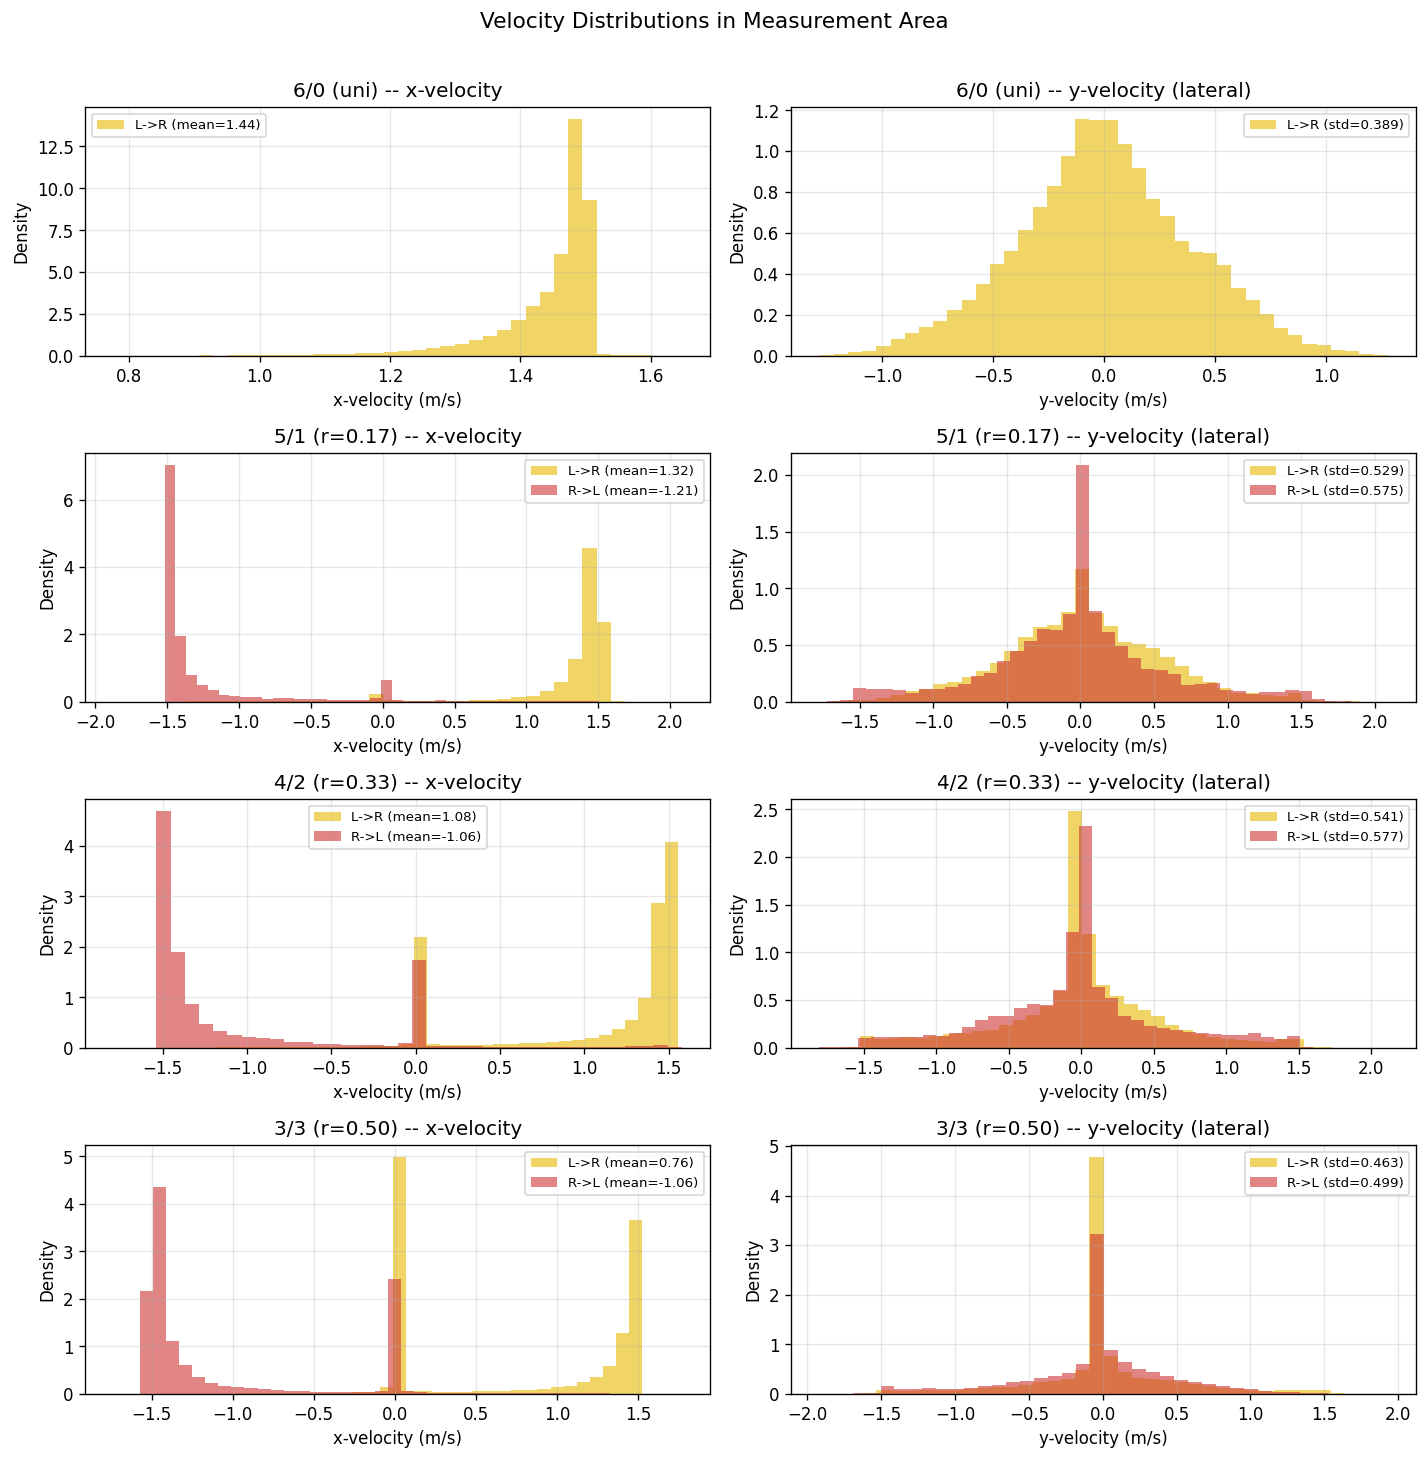

In [15]:
def collect_measurement_velocities(
    rec: TrajectoryRecord,
    x_min: float = MEASURE_START,
    x_max: float = MEASURE_END,
) -> dict:
    """Collect velocity statistics from the measurement area."""
    vx_left = []   # left-to-right agents
    vx_right = []  # right-to-left agents
    vy_left = []
    vy_right = []

    for t_idx in range(len(rec.times)):
        pos = rec.positions[t_idx]
        vel = rec.velocities[t_idx]
        active = rec.active_mask[t_idx]

        in_area = active & (pos[:, 0] >= x_min) & (pos[:, 0] <= x_max)

        for i in range(rec.n_agents):
            if not in_area[i]:
                continue
            if rec.dir_labels[i] > 0:
                vx_left.append(vel[i, 0])
                vy_left.append(vel[i, 1])
            else:
                vx_right.append(vel[i, 0])
                vy_right.append(vel[i, 1])

    return {
        "vx_left": np.array(vx_left),
        "vx_right": np.array(vx_right),
        "vy_left": np.array(vy_left),
        "vy_right": np.array(vy_right),
    }


# Plot velocity distributions for all configs
fig, axes = plt.subplots(len(results), 2, figsize=(12, 3 * len(results)))

for row, (name, rec) in enumerate(results.items()):
    stats = collect_measurement_velocities(rec)

    # x-velocity histogram
    ax = axes[row, 0]
    if len(stats["vx_left"]) > 0:
        ax.hist(stats["vx_left"], bins=40, alpha=0.6, color="#e6b800",
                label=f"L->R (mean={np.mean(stats['vx_left']):.2f})", density=True)
    if len(stats["vx_right"]) > 0:
        ax.hist(stats["vx_right"], bins=40, alpha=0.6, color="#cc3333",
                label=f"R->L (mean={np.mean(stats['vx_right']):.2f})", density=True)
    ax.set_xlabel("x-velocity (m/s)")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} -- x-velocity")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # y-velocity histogram
    ax = axes[row, 1]
    if len(stats["vy_left"]) > 0:
        ax.hist(stats["vy_left"], bins=40, alpha=0.6, color="#e6b800",
                label=f"L->R (std={np.std(stats['vy_left']):.3f})", density=True)
    if len(stats["vy_right"]) > 0:
        ax.hist(stats["vy_right"], bins=40, alpha=0.6, color="#cc3333",
                label=f"R->L (std={np.std(stats['vy_right']):.3f})", density=True)
    ax.set_xlabel("y-velocity (m/s)")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} -- y-velocity (lateral)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Velocity Distributions in Measurement Area", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 11. Crossing Time

Measure how long it takes each agent to traverse the measurement area (10m).
Reference: Feliciani Table II reports ~7.3s average crossing time.

In [16]:
def compute_crossing_times(
    rec: TrajectoryRecord,
    x_start: float = MEASURE_START,
    x_end: float = MEASURE_END,
) -> dict:
    """Compute the time each agent takes to cross the measurement area.

    Returns dict with 'left' and 'right' crossing time arrays.
    """
    ct_left = []
    ct_right = []

    for i in range(rec.n_agents):
        traj_x = rec.positions[:, i, 0]

        if rec.dir_labels[i] > 0:
            # Left-to-right: enters at x_start, exits at x_end
            enter_frames = np.where(traj_x >= x_start)[0]
            exit_frames = np.where(traj_x >= x_end)[0]
        else:
            # Right-to-left: enters at x_end, exits at x_start
            enter_frames = np.where(traj_x <= x_end)[0]
            exit_frames = np.where(traj_x <= x_start)[0]

        if len(enter_frames) == 0 or len(exit_frames) == 0:
            continue

        enter_time = rec.times[enter_frames[0]]
        exit_time = rec.times[exit_frames[0]]

        if exit_time > enter_time:
            ct = exit_time - enter_time
            if rec.dir_labels[i] > 0:
                ct_left.append(ct)
            else:
                ct_right.append(ct)

    return {"left": np.array(ct_left), "right": np.array(ct_right)}


print("Crossing times (measurement area, 10m):")
print(f"{'Config':<20} {'All':>15} {'Major flow':>15} {'Minor flow':>15}")
print("-" * 68)

for name, rec in results.items():
    ct = compute_crossing_times(rec)
    all_ct = np.concatenate([ct["left"], ct["right"]]) if len(ct["right"]) > 0 else ct["left"]

    if len(all_ct) > 0:
        all_str = f"{np.mean(all_ct):.2f} +/- {np.std(all_ct):.2f}s"
    else:
        all_str = "N/A"

    if len(ct["left"]) > 0:
        left_str = f"{np.mean(ct['left']):.2f} +/- {np.std(ct['left']):.2f}s"
    else:
        left_str = "N/A"

    if len(ct["right"]) > 0:
        right_str = f"{np.mean(ct['right']):.2f} +/- {np.std(ct['right']):.2f}s"
    else:
        right_str = "--"

    print(f"{name:<20} {all_str:>15} {left_str:>15} {right_str:>15}")

print("\nReference (Feliciani 2016, Table II):")
print(f"{'6/0':<20} {'7.27 +/- 0.32s':>15}")
print(f"{'5/1':<20} {'7.31 +/- 0.56s':>15} {'7.40 +/- 0.47s':>15} {'6.87 +/- 0.77s':>15}")
print(f"{'4/2':<20} {'7.27 +/- 0.58s':>15} {'7.37 +/- 0.57s':>15} {'7.07 +/- 0.55s':>15}")
print(f"{'3/3':<20} {'7.33 +/- 0.59s':>15} {'7.49 +/- 0.61s':>15} {'7.16 +/- 0.53s':>15}")

Crossing times (measurement area, 10m):
Config                           All      Major flow      Minor flow
--------------------------------------------------------------------
6/0 (uni)             6.93 +/- 0.14s  6.93 +/- 0.14s              --
5/1 (r=0.17)          7.69 +/- 0.92s  7.57 +/- 0.66s  8.30 +/- 1.57s
4/2 (r=0.33)          9.33 +/- 1.88s  9.28 +/- 1.68s  9.43 +/- 2.23s
3/3 (r=0.50)         11.33 +/- 3.79s 13.24 +/- 3.19s  9.42 +/- 3.36s

Reference (Feliciani 2016, Table II):
6/0                   7.27 +/- 0.32s
5/1                   7.31 +/- 0.56s  7.40 +/- 0.47s  6.87 +/- 0.77s
4/2                   7.27 +/- 0.58s  7.37 +/- 0.57s  7.07 +/- 0.55s
3/3                   7.33 +/- 0.59s  7.49 +/- 0.61s  7.16 +/- 0.53s


## 12. 2D Velocity Field Visualisation

Visualise the average x-velocity on a 2D grid (matching Feliciani Fig. 14),
where yellow = major flow direction and red = minor flow direction.

/tmp/ipykernel_1848552/3602355344.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


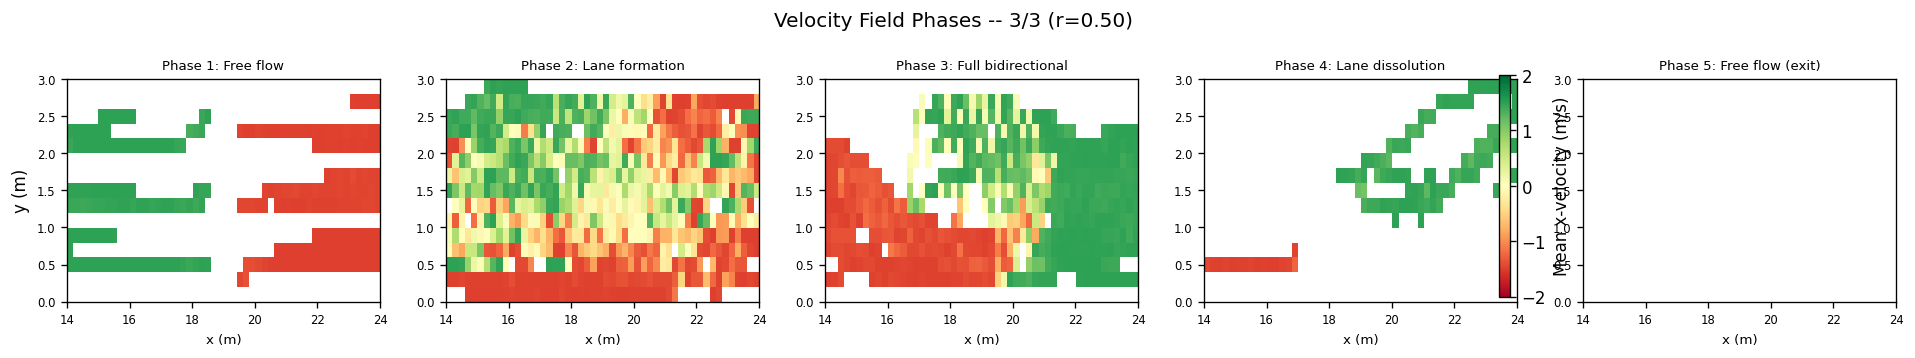

In [17]:
def compute_velocity_grid(
    rec: TrajectoryRecord,
    t_start: float = None,
    t_end: float = None,
    cell_size: float = 0.2,
    x_min: float = MEASURE_START,
    x_max: float = MEASURE_END,
) -> np.ndarray:
    """Compute mean x-velocity on a 2D grid, averaged over time window."""
    nx = int(np.ceil((x_max - x_min) / cell_size))
    ny = int(np.ceil(CORRIDOR_WIDTH / cell_size))

    vx_sum = np.zeros((ny, nx))
    count = np.zeros((ny, nx))

    for t_idx in range(len(rec.times)):
        t = rec.times[t_idx]
        if t_start is not None and t < t_start:
            continue
        if t_end is not None and t > t_end:
            break

        pos = rec.positions[t_idx]
        vel = rec.velocities[t_idx]
        active = rec.active_mask[t_idx]

        for i in range(rec.n_agents):
            if not active[i]:
                continue
            if pos[i, 0] < x_min or pos[i, 0] > x_max:
                continue
            ix = min(int((pos[i, 0] - x_min) / cell_size), nx - 1)
            iy = min(int(pos[i, 1] / cell_size), ny - 1)
            vx_sum[iy, ix] += vel[i, 0]
            count[iy, ix] += 1

    with np.errstate(divide="ignore", invalid="ignore"):
        vx_mean = np.where(count > 0, vx_sum / count, np.nan)

    return vx_mean


# Plot for 3/3 balanced case at different time windows
balanced_name = [n for n in results if "3/3" in n][0]
rec = results[balanced_name]
T = rec.times[-1]

phases = [
    ("Phase 1: Free flow", 0, T * 0.15),
    ("Phase 2: Lane formation", T * 0.15, T * 0.35),
    ("Phase 3: Full bidirectional", T * 0.35, T * 0.65),
    ("Phase 4: Lane dissolution", T * 0.65, T * 0.85),
    ("Phase 5: Free flow (exit)", T * 0.85, T),
]

fig, axes = plt.subplots(1, len(phases), figsize=(16, 3))

for ax, (title, t0, t1) in zip(axes, phases):
    vx_grid = compute_velocity_grid(rec, t_start=t0, t_end=t1)
    im = ax.imshow(
        vx_grid, origin="lower", aspect="auto",
        extent=[MEASURE_START, MEASURE_END, 0, CORRIDOR_WIDTH],
        cmap="RdYlGn", vmin=-2, vmax=2,
    )
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("x (m)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("y (m)")
fig.colorbar(im, ax=axes, label="Mean x-velocity (m/s)", shrink=0.8)
fig.suptitle(f"Velocity Field Phases -- {balanced_name}", fontsize=12)
fig.tight_layout()
plt.show()

## 13. Snapshot Visualisation

Show agent positions at key time points, with elliptical bodies, direction
arrows, and colour-coded by group.

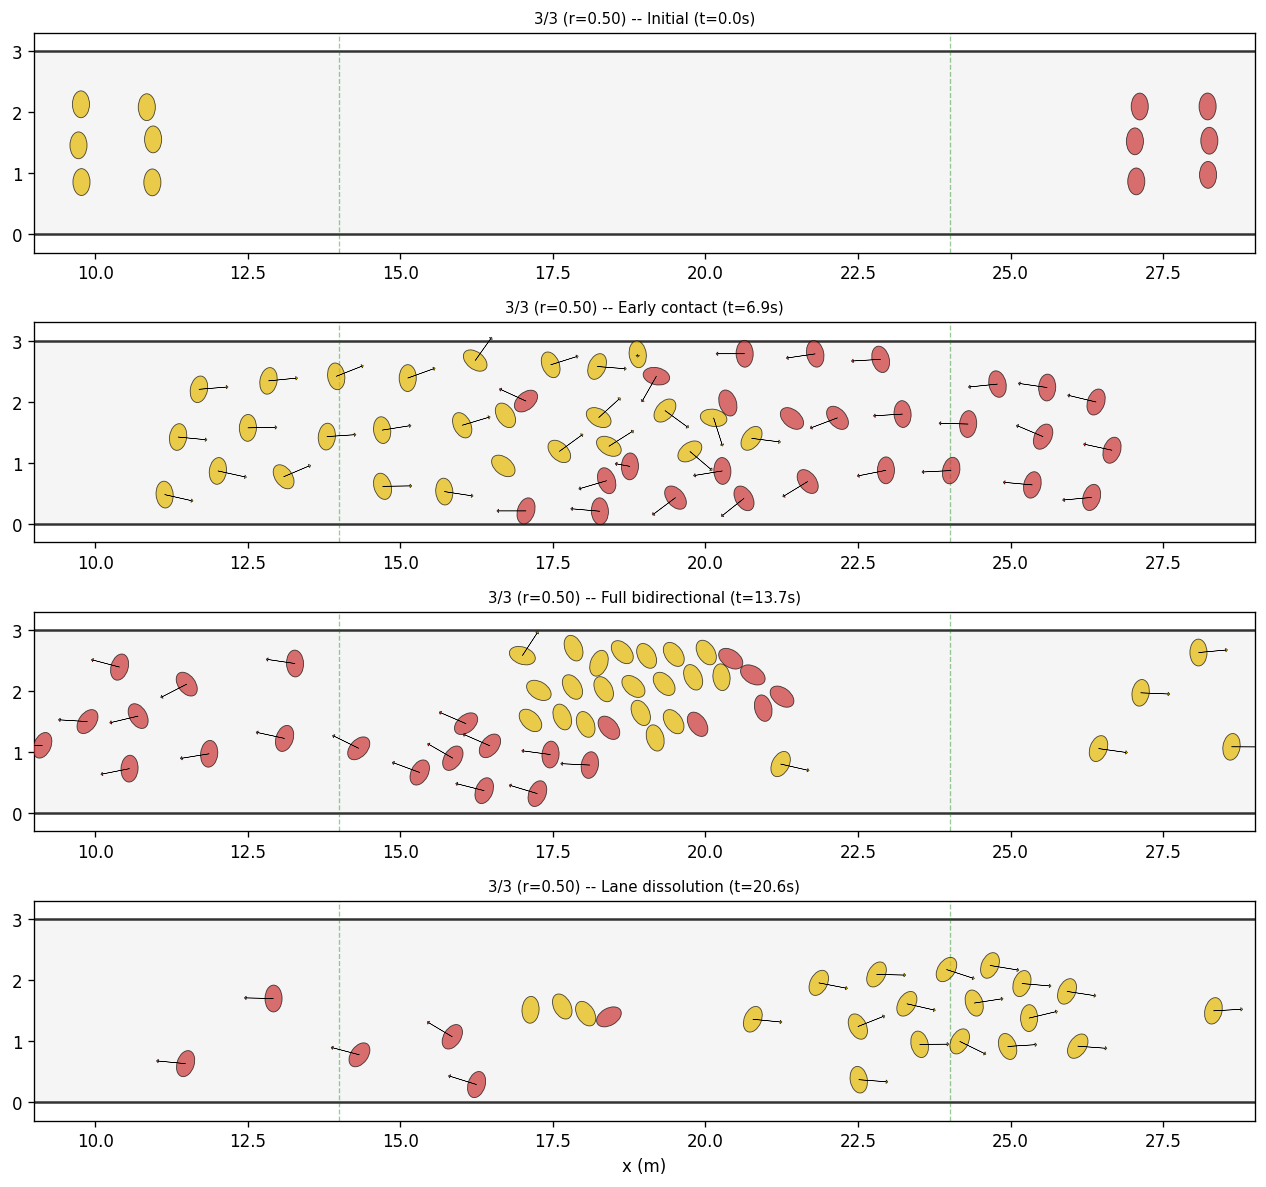

In [18]:
def plot_snapshot(
    rec: TrajectoryRecord,
    t_idx: int,
    ax,
    title: str = "",
    show_measurement_area: bool = True,
    xlim: tuple = None,
):
    """Plot a snapshot of agent positions at a specific time index."""
    # Corridor
    coords = np.array(rec.polygon.exterior.coords)
    ax.add_patch(mpatches.Polygon(coords, fc="#f5f5f5", ec="#333", lw=1.5, zorder=1))

    if show_measurement_area:
        ax.axvline(MEASURE_START, color="green", ls="--", alpha=0.4, lw=0.8)
        ax.axvline(MEASURE_END, color="green", ls="--", alpha=0.4, lw=0.8)

    pos = rec.positions[t_idx]
    vel = rec.velocities[t_idx]
    active = rec.active_mask[t_idx]

    for i in range(rec.n_agents):
        if not active[i]:
            continue

        color = "#e6b800" if rec.dir_labels[i] > 0 else "#cc3333"

        # Elliptical body
        ellipse = mpatches.Ellipse(
            pos[i], width=0.28, height=0.44,
            angle=np.degrees(rec.torso_angles[t_idx, i]),
            facecolor=color, edgecolor="black", lw=0.5, alpha=0.7, zorder=10,
        )
        ax.add_patch(ellipse)

        # Velocity arrow
        speed = np.linalg.norm(vel[i])
        if speed > 0.05:
            ax.arrow(
                pos[i, 0], pos[i, 1],
                vel[i, 0] * 0.3, vel[i, 1] * 0.3,
                head_width=0.06, head_length=0.03,
                fc=color, ec="black", lw=0.3, zorder=11,
            )

    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_xlim(-0.5, CORRIDOR_LENGTH + 0.5)
    ax.set_ylim(-0.3, CORRIDOR_WIDTH + 0.3)
    ax.set_aspect("equal")
    ax.set_title(f"{title} (t={rec.times[t_idx]:.1f}s)", fontsize=9)


# Show snapshots for 3/3 balanced case at key moments
rec = results[balanced_name]
n_frames = len(rec.times)
snapshot_indices = [
    0,
    n_frames // 5,
    2 * n_frames // 5,
    3 * n_frames // 5,
]

fig, axes = plt.subplots(len(snapshot_indices), 1, figsize=(14, 2.5 * len(snapshot_indices)))
labels = ["Initial", "Early contact", "Full bidirectional", "Lane dissolution"]

for ax, idx, label in zip(axes, snapshot_indices, labels):
    plot_snapshot(rec, idx, ax, title=f"{balanced_name} -- {label}",
                  xlim=(MEASURE_START - 5, MEASURE_END + 5))

axes[-1].set_xlabel("x (m)")
fig.tight_layout()
plt.show()

## 14. Summary

Compile all metrics into a summary table comparing CrowdRL results against
the Feliciani & Nishinari (2016) empirical reference values.

In [19]:
print("=" * 72)
print("LANE FORMATION BENCHMARK SUMMARY")
print("=" * 72)

# Reference values from Feliciani & Nishinari (2016)
ref_phi = {"5/1": (0.824, 0.130), "4/2": (0.881, 0.131), "3/3": (0.938, 0.105)}
ref_ct = {
    "6/0": (7.273, 0.319),
    "5/1": (7.309, 0.561),
    "4/2": (7.266, 0.580),
    "3/3": (7.326, 0.592),
}

print(f"\n{'Config':<18} {'Order Param':>18} {'Ref Phi':>18} {'Crossing Time':>18} {'Ref CT':>18}")
print("-" * 92)

for name, rec in results.items():
    # Order parameter
    if rec.dir_labels.min() < 0:
        times, phis = compute_order_parameter_timeseries(rec)
        valid = ~np.isnan(phis)
        mid = valid & (times >= times[valid][len(times[valid])//4]) & (times <= times[valid][3*len(times[valid])//4])
        if np.any(mid):
            phi_str = f"{np.nanmean(phis[mid]):.3f} +/- {np.nanstd(phis[mid]):.3f}"
        else:
            phi_str = "N/A"
    else:
        phi_str = "1.000 (uni)"

    # Reference phi
    config_key = name.split(" ")[0]
    if config_key in ref_phi:
        ref_phi_str = f"{ref_phi[config_key][0]:.3f} +/- {ref_phi[config_key][1]:.3f}"
    else:
        ref_phi_str = "1.000 (uni)"

    # Crossing time
    ct = compute_crossing_times(rec)
    all_ct = np.concatenate([ct["left"], ct["right"]]) if len(ct["right"]) > 0 else ct["left"]
    if len(all_ct) > 0:
        ct_str = f"{np.mean(all_ct):.2f} +/- {np.std(all_ct):.2f}s"
    else:
        ct_str = "N/A"

    if config_key in ref_ct:
        ref_ct_str = f"{ref_ct[config_key][0]:.2f} +/- {ref_ct[config_key][1]:.2f}s"
    else:
        ref_ct_str = "N/A"

    print(f"{name:<18} {phi_str:>18} {ref_phi_str:>18} {ct_str:>18} {ref_ct_str:>18}")

print("\n" + "=" * 72)
print("Notes:")
print("- Order parameter Phi: 1.0 = perfect lanes, 0.0 = random mixing")
print("- Reference values from Feliciani & Nishinari, Phys. Rev. E 94, 032304 (2016)")
print("- Crossing time = time to traverse 10m measurement area")
print("- CrowdRL agents were NEVER trained on bidirectional flow scenarios")
print("  -> lane formation is an emergent behaviour from goal-reaching training")

LANE FORMATION BENCHMARK SUMMARY

Config                    Order Param            Ref Phi      Crossing Time             Ref CT
--------------------------------------------------------------------------------------------
6/0 (uni)                 1.000 (uni)        1.000 (uni)     6.93 +/- 0.14s     7.27 +/- 0.32s
5/1 (r=0.17)          0.778 +/- 0.075    0.824 +/- 0.130     7.69 +/- 0.92s     7.31 +/- 0.56s
4/2 (r=0.33)          0.564 +/- 0.088    0.881 +/- 0.131     9.33 +/- 1.88s     7.27 +/- 0.58s
3/3 (r=0.50)          0.636 +/- 0.126    0.938 +/- 0.105    11.33 +/- 3.79s     7.33 +/- 0.59s

Notes:
- Order parameter Phi: 1.0 = perfect lanes, 0.0 = random mixing
- Reference values from Feliciani & Nishinari, Phys. Rev. E 94, 032304 (2016)
- Crossing time = time to traverse 10m measurement area
- CrowdRL agents were NEVER trained on bidirectional flow scenarios
  -> lane formation is an emergent behaviour from goal-reaching training


## 15. Next Steps

1. **Compare with JuPedSim models**: Run the same corridor with CollisionFreeSpeedModel
   and GCFM (requires `crowdrl-jupedsim` adapter -- Milestone M9)
2. **Statistical robustness**: Run each configuration N=10 times with different seeds
3. **Bottleneck benchmark**: `09_bottleneck_test.ipynb` -- faster-is-slower effect
4. **Ablation**: Test 2D (speed+heading only) vs 3D vs 4D action spaces
5. **Density sweep**: Vary agent count (27, 54, 81, 108) to test density effects

See `plan/validation_benchmark_plan.md` for the full validation roadmap.